**WILKISTER KAWIRA**


**Abstract**: This project aims to identify accident Black spot locations in Kenya by mapping all accidents that have been recorded between 2012 and 2023. A risk factor is then assigned to road segments and used to calculate safer routes to reduce accidents . Here I  focus mainly on predicting safer routes within Nairobi County .


**ACCESS**

In [ ]:
%%capture
%pip install osmnx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  folium
import geopandas as gpd
from shapely.geometry import Point

In [ ]:
!git clone https://github.com/will-genius/fynesse_template.git
import os, subprocess, importlib, sys
sys.path.append("/content/fynesse_template")
import fynesse


Cloning into 'fynesse_template'...
remote: Enumerating objects: 288, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 288 (delta 35), reused 27 (delta 20), pack-reused 240 (from 4)
Receiving objects: 100% (288/288), 177.09 KiB | 5.71 MiB/s, done.
Resolving deltas: 100% (137/137), done.


In [ ]:
! git clone https://github.com/will-genius/mlfcworkshop.git
%cd mlfcworkshop

Cloning into 'mlfcworkshop'...
remote: Enumerating objects: 229, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 229 (delta 6), reused 0 (delta 0), pack-reused 204 (from 2)
Receiving objects: 100% (229/229), 107.21 MiB | 8.08 MiB/s, done.
Resolving deltas: 100% (89/89), done.
Updating files: 100% (52/52), done.
/content/mlfcworkshop


In [ ]:
df= pd.read_csv("Data/ma3route_crashes_algorithmcode.csv")
df.head()

,crash_id,crash_datetime,crash_date,latitude,longitude,n_crash_reports,contains_fatality_words,contains_pedestrian_words,contains_matatu_words,contains_motorcycle_words
0,1,2018-06-06 20:39:54,2018-06-06,-1.263030,36.764374,1,0,0,0,0
1,2,2018-08-17 06:15:54,2018-08-17,-0.829710,37.037820,1,1,0,0,0
2,3,2018-05-25 17:51:54,2018-05-25,-1.125301,37.003297,1,0,0,0,0
3,4,2018-05-25 18:11:54,2018-05-25,-1.740958,37.129026,1,0,0,0,0
4,5,2018-05-25 21:59:54,2018-05-25,-1.259392,36.842321,1,1,0,0,0


The data to be used shall be from the ma3route_crashes_algorithmcode.csv from the World Bank microdata Library with Kenyan road accident Data as from 2012 t0 2023  https://microdata.worldbank.org/index.php/catalog/6249

Now we try to understand the data we have and confirm the crashes are within the Kenyan bourders by checking min and max latitude and longitude. We divide the datetime column into month, year hour and day of weak for later use and convert the data into a geodataframe

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31064 entries, 0 to 31063
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   crash_id                   31064 non-null  int64  
 1   crash_datetime             31064 non-null  object 
 2   crash_date                 31064 non-null  object 
 3   latitude                   31064 non-null  float64
 4   longitude                  31064 non-null  float64
 5   n_crash_reports            31064 non-null  int64  
 6   contains_fatality_words    31064 non-null  int64  
 7   contains_pedestrian_words  31064 non-null  int64  
 8   contains_matatu_words      31064 non-null  int64  
 9   contains_motorcycle_words  31064 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 2.4+ MB


In [ ]:
df['crash_datetime'] = pd.to_datetime(df['crash_datetime'], errors='coerce')
df['crash_date'] = pd.to_datetime(df['crash_date'], errors='coerce')
print("lat range:", df['latitude'].min(), df['latitude'].max())
print("lon range:", df['longitude'].min(), df['longitude'].max())

lat range: -3.10000000200807 -0.565402313796744
lon range: 36.2839500025994 37.8794900005407


In [ ]:
df['month'] = df['crash_datetime'].dt.month
df['year'] = df['crash_datetime'].dt.year
df['hour'] = df['crash_datetime'].dt.hour
df['dayofweek'] = df['crash_datetime'].dt.dayofweek

In [ ]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs='EPSG:4326')

In [ ]:
gdf.to_file("crashes_cleaned.geojson", driver="GeoJSON")
gdf.to_csv("crashes_cleaned.csv", index=False)

**Assess** :

we shall now try to figure out if:

  There Are there months with higher accident rates ?

  What times of day see most accidents?

  Hotspots mapping


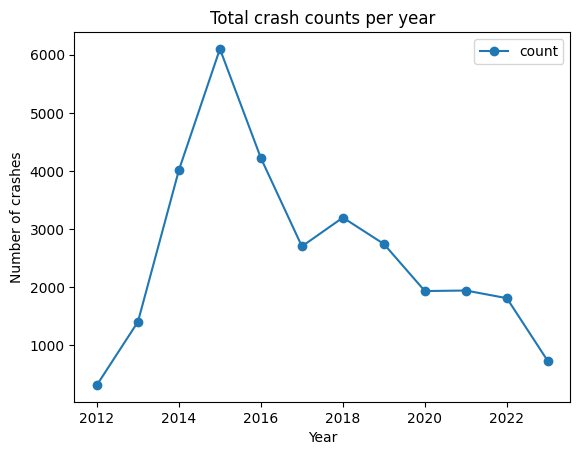

In [ ]:
fynesse.assess.plot_crash_trends(gdf) #visualisation of accident trend over the years

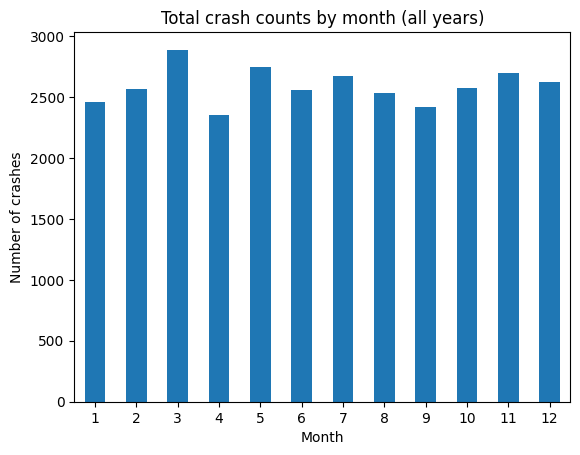

In [ ]:
fynesse.assess.plot_monthly_totals(gdf)

This shows that there is no particular patern for accident occurences per month over the years, However 2015 seems to have had the highest reported accident cases.

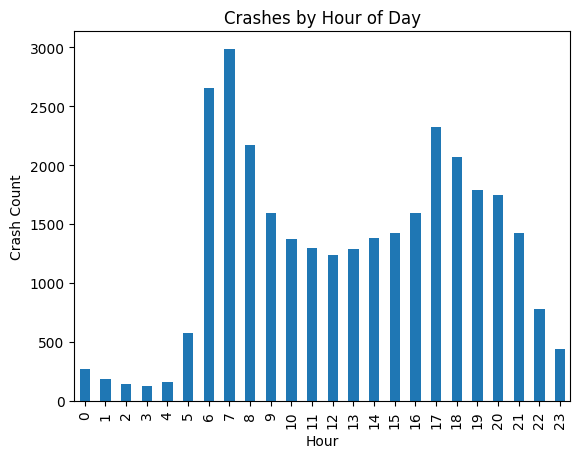

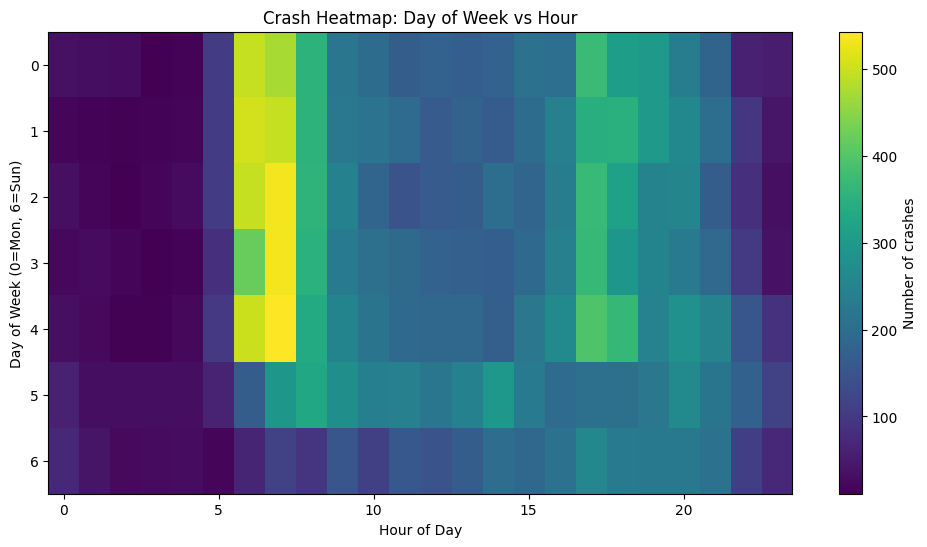

In [ ]:
fynesse.assess.plot_hourly_patterns(gdf)

In [ ]:
fynesse.assess.plot_crash_map(gdf, country_name="Kenya")

This tell us that most accidents occured in the morning between 6 to 8 am and in the evening between 5 and 7 am.
The hetmap shows that this trend is mainly during the week days with weekend having fewer accidents, thus we can comfortably assume that the main cause of this accidents is people russhing to and from work or school on weekdays

Here I created a Folium map for each accident that took place to its location

Next I will assign risk to each road segment for the 5 counties covered by my data. To see the risk factors assigned to rads in a particular county the user simply selects the county and gets as output the crash count per road segment.

In [ ]:
fynesse.assess.risk_visualizer(gdf, lon_col="longitude", lat_col="latitude") # defaults to Nairobi road networks if no county is specified

,u,v,key,name,crash_count,risk
70901,6694295778,3675697249,0,Thika Road Service Lane,1190,1190
16637,1506607102,1506607043,0,Unnamed road,769,769
75672,7612038551,7612038553,0,Unnamed road,757,757
2533,280701813,2959986467,0,Mombasa Road,723,723
21361,2398806058,1948521871,0,Thika Road,560,560
45511,6303567890,7804194484,0,Unnamed road,443,443
74240,7361675030,2475526200,0,Lower Kabete Road,340,340
26646,3729152279,306358098,0,Mombasa Road,339,339
25848,3184419011,3143185595,0,Airport North Road,330,330
39005,6167007904,6167007905,0,Unnamed road,320,320


**Address**:

I shall now try to come up with an alternative route recomendation

I will be using Nairobi city road network so first I shall load it from the pre-saved graphml to prevent reloading each time thus save time

In [ ]:
import osmnx as ox
cache_dir="cached_graphs"
county_name = 'Nairobi, Kenya'
safe_name = county_name.replace(" ", "_").replace(",", "")
graph_path = os.path.join(cache_dir, f"{safe_name}.graphml")

if os.path.exists(graph_path):
    print(f" Loading cached graph for {county_name}...")
    G = ox.load_graphml(graph_path)

 Loading cached graph for Nairobi, Kenya...


In [ ]:
crash_gdf, G = fynesse.address.assign_crash_risk_to_edges(G, gdf, lon_col="longitude", lat_col="latitude")

Assigned risk values to graph edges.


In [ ]:
fynesse.address.plot_routes_in_nairobi(G)
# To enter a different start and destination location manually set the start and destination argument in the function call
#plot_routes_in_nairobi(G, start_place="JKIA", end_place="Westlands")

First I found edges nearest to each crash point then calculated the number of crashes per edge to help me know the nmber of accdents that occured for each section of a certain road. This aided in the assignment of a risk factor.The weight function helps find a safer route without too many unnecessary detours by considering the risk factorand  the length of the road.the result was

Shortest route (blue): normal shortest path using only length.

Safe route (red): risk-aware path using our custom cost function.

Sometimes the safest route is alsso the shortest so the blue is not plotted .
